In [2]:
import numpy as np
from mesoscopy.resources import get_atlas, get_atlas_annotations
import matplotlib.pyplot as plt
from mesoscopy import io
from mesoscopy.process import region


In [3]:
# f = io.read_h5("../scratch/sub-test_exp-testexp_meso_date-2025-05-20T14_42_39_preprocessed_registered.h5")
f = io.read_h5("../scratch/sub-TT712_exp-10hrb25ce_meso_date-2025-05-15T16_29_37_preprocessed_registered.h5")

In [4]:
l_aba, r_aba = get_atlas()

In [5]:
l_aba

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(140, 142), dtype=uint16)

In [6]:
mask = np.broadcast_to(l_aba == 578, f["F"].shape)

np.ma.array(f["F"], mask=~mask)

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --,

In [7]:
annotations = get_atlas_annotations()
annotations

,id,acronym,name
0,11,SSp-ul,Primary somatosensory area upper limb
1,97,AUDd1,Dorsal auditory area
2,104,AUDp1,Primary auditory area
3,111,AUDpo1,Posterior auditory area
4,118,AUDv1,Ventral auditory area
5,395,FRP1,Frontal pole
6,578,MOp1,Primary motor area
7,584,MOs,Secondary motor area
8,665,ORBm1,Orbital area medial part
9,753,PL1,Prelimbic area


In [8]:
annotations.loc[annotations["acronym"] == "VISli1", "id"].values[0]

np.int64(1214)

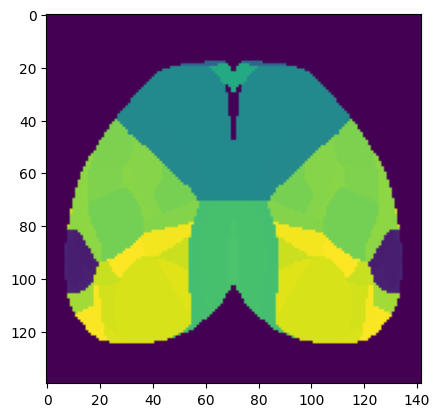

In [9]:
plt.imshow(l_aba + r_aba)

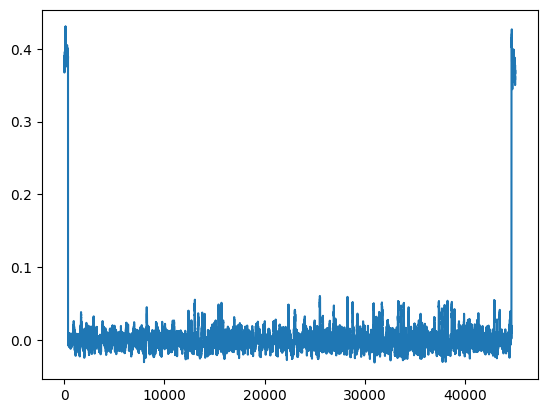

In [10]:
plt.plot(np.ma.array(f["F"], mask=~mask).mean(axis=(1, 2)))

In [11]:
get_atlas_annotations().acronym.unique()

array(['SSp-ul', 'AUDd1', 'AUDp1', 'AUDpo1', 'AUDv1', 'FRP1', 'MOp1',
       'MOs', 'ORBm1', 'PL1', 'RSPagl1', 'RSPd1', 'RSPv1', 'SSp-bfd1',
       'SSp-ll1', 'SSp-m1', 'SSp-n1', 'SSp-tr1', 'SSp-ul1', 'SSp-un1',
       'SSs1', 'TEa1', 'VISal1', 'VISam1', 'VISC1', 'VISl1', 'VISp',
       'VISpl1', 'VISpm', 'VISa1', 'VISli1', 'VISpor1', 'VISrl1'],
      dtype=object)

In [12]:
region_activity = region.extract_all_regions(deltaf_series=f["F"][1000:3000])

In [13]:
region_activity

{'L_SSp-ul': masked_array(data=[0.006696587894111872, 0.004767163656651974,
                    0.000791934784501791, ..., -0.0030872286297380924,
                    -0.0025738729164004326, -0.008355200290679932],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_SSp-ul': masked_array(data=[0.013162602670490742, 0.0022261962294578552,
                    0.005490864161401987, ..., -0.004024984780699015,
                    0.006603638641536236, -0.005593894515186548],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'L_MOp1': masked_array(data=[0.0050218402197534555, 0.001145734526645178,
                    0.003507521874146443, ..., -0.01002270965283858,
                    -0.010019475016100654, -0.011747975002303434],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_MOp1': masked_array(data=[0.0036452446860828617, -0.00014634127817848177

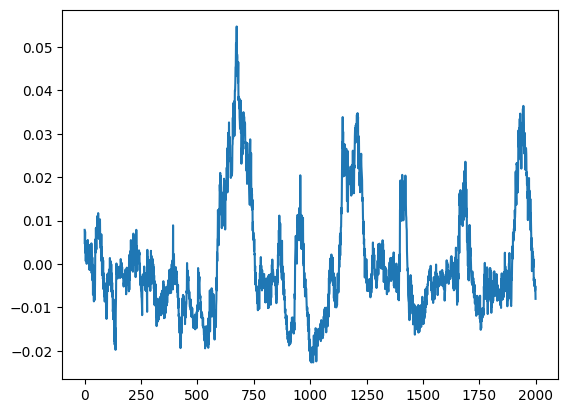

In [14]:
plt.plot(region_activity["L_MOs"])

In [15]:
import pandas as pd


In [16]:
df = pd.DataFrame(region_activity)

In [17]:
df.unstack().reset_index().rename(columns={"level_0": "region", "level_1": "time_idx", 0: "F"})

,region,time_idx,F
0,L_SSp-ul,0,0.006697
1,L_SSp-ul,1,0.004767
2,L_SSp-ul,2,0.000792
3,L_SSp-ul,3,0.005402
4,L_SSp-ul,4,0.011726
...,...,...,...
91995,R_VISrl1,1995,-0.006175
91996,R_VISrl1,1996,-0.007681
91997,R_VISrl1,1997,-0.007714
91998,R_VISrl1,1998,-0.010786
